In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('R:/PROJECTS/Superstore_Sales_Analysis/Sample - Superstore.csv',encoding='windows-1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
# Changing columns names to lower case and replacing spaces with underscores
print("Columns before renaming:\n")
print(df.columns)
print("--------------------------------------------------------------------------------------")
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns = df.columns.str.replace('-', '_')
print("\nColumns after renaming:\n")
print(df.columns)

Columns before renaming:

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')
--------------------------------------------------------------------------------------

Columns after renaming:

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='str')


In [5]:
#  Descriptive statistics of the dataset
df.describe()

,row_id,postal_code,sales,quantity,discount,profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [6]:
# Changing the data type of 'Order Date' and 'Ship Date' columns to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

In [7]:
# Creating a new column 'shipping_time' to calculate the difference between 'ship_date' and 'order_date'
df['shipping_time'] = (df['ship_date'] - df['order_date']).dt.days

# Creating a new column 'profit_margin' to calculate the profit margin for each order
df['profit_margin'] = (df['profit'] / df['sales']) * 100

# Creating a new column 'order_month', 'order_year' and 'order_day_of_week' to extract the month and year from 'order_date'
df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year
df['order_day_of_week'] = df['order_date'].dt.day_of_week

In [8]:
# Checking for missing values in the dataset
df.isnull().sum()

row_id               0
order_id             0
order_date           0
ship_date            0
ship_mode            0
customer_id          0
customer_name        0
segment              0
country              0
city                 0
state                0
postal_code          0
region               0
product_id           0
category             0
sub_category         0
product_name         0
sales                0
quantity             0
discount             0
profit               0
shipping_time        0
profit_margin        0
order_month          0
order_year           0
order_day_of_week    0
dtype: int64

In [9]:
# Checking for duplicate values in the dataset
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis 

In [10]:
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit',
       'shipping_time', 'profit_margin', 'order_month', 'order_year',
       'order_day_of_week'],
      dtype='str')

In [11]:
df['order_date'].sort_values(ascending=True).reset_index()

,index,order_date
0,7980,2014-01-03
1,739,2014-01-04
2,740,2014-01-04
3,741,2014-01-04
4,1759,2014-01-05
...,...,...
9989,5091,2017-12-30
9990,908,2017-12-30
9991,907,2017-12-30
9992,1296,2017-12-30


In [12]:
df['order_date'].min(), df['order_date'].max()

(Timestamp('2014-01-03 00:00:00'), Timestamp('2017-12-30 00:00:00'))

In [13]:
# Number of orders per month
orders_per_month = df.groupby('order_month').size()
orders_per_month



order_month
1      381
2      300
3      696
4      668
5      735
6      717
7      710
8      706
9     1383
10     819
11    1471
12    1408
dtype: int64

Text(0.5, 1.0, 'Number of Orders per Month')

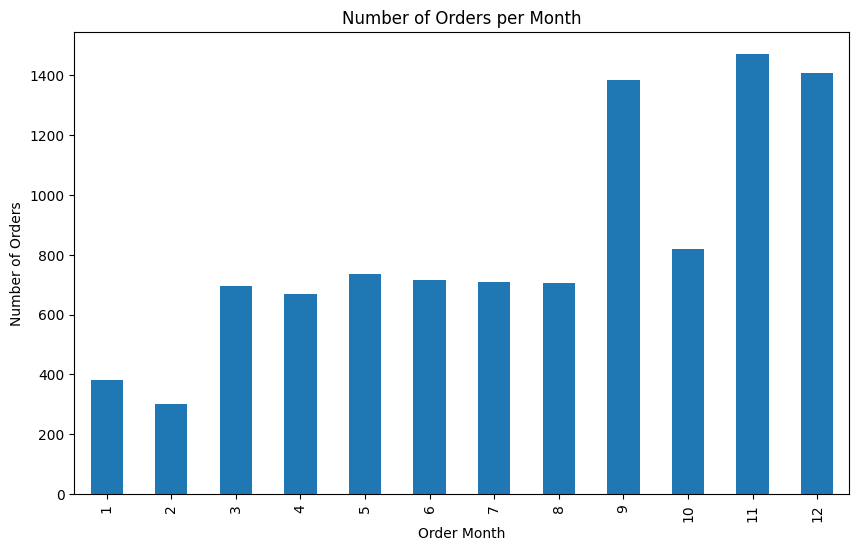

In [14]:
# Visulaizing the number of orders per month using a bar chart
plt.figure(figsize=(10,6))
orders_per_month.plot(kind='bar')
plt.xlabel('Order Month')
plt.ylabel('Number of Orders')
plt.title('Number of Orders per Month')

In [15]:
# Number of shipped orders per month
shipped_orders_per_month = df['ship_date'].groupby(df['order_month']).size()
shipped_orders_per_month

order_month
1      381
2      300
3      696
4      668
5      735
6      717
7      710
8      706
9     1383
10     819
11    1471
12    1408
Name: ship_date, dtype: int64

Text(0.5, 1.0, 'Number of Shipped Orders per Month')

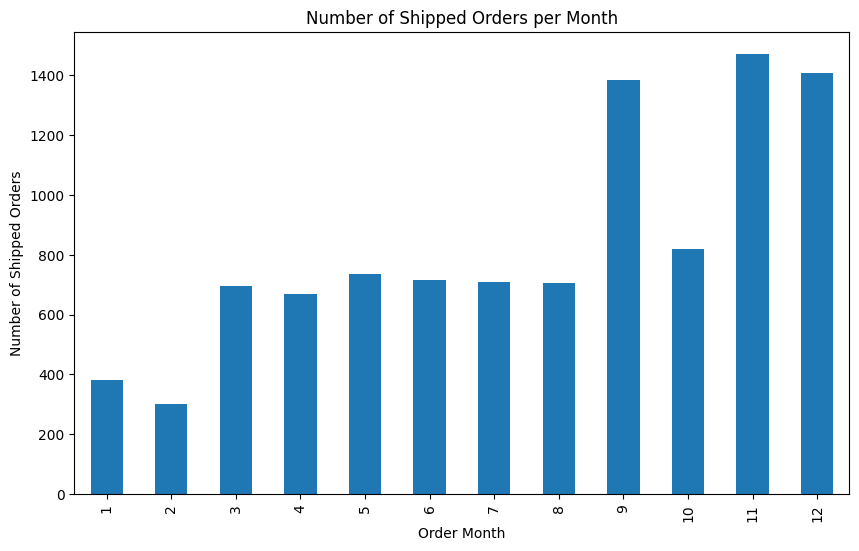

In [16]:
# Visulaizing the number of orders per month using a bar chart
plt.figure(figsize=(10,6))
shipped_orders_per_month.plot(kind='bar')
plt.xlabel('Order Month')
plt.ylabel('Number of Shipped Orders')
plt.title('Number of Shipped Orders per Month')

In [17]:
print('Do the number of orders and shipped orders per month match?:', orders_per_month.equals(shipped_orders_per_month))

Do the number of orders and shipped orders per month match?: True


In [18]:
df['ship_mode'].unique() #Unique shipping modes available in the dataset

<ArrowStringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str

In [19]:
print(df['segment'].unique()) #Unique segments available in the dataset
print(df['segment'].value_counts()) #Count of each segment in the dataset

<ArrowStringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


In [20]:
print(df['category'].unique()) #Unique categories available in the dataset
print(df['category'].value_counts()) #Count of each category in the dataset

<ArrowStringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


In [21]:
print(df['sub_category'].unique()) #Unique sub-categories available in the dataset
print(df['sub_category'].value_counts()) #Count of each sub-category in the dataset

<ArrowStringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str
sub_category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


### Monthly Sales

In [23]:
df

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_name,sales,quantity,discount,profit,shipping_time,profit_margin,order_month,order_year,order_day_of_week
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,16.00,11,2016,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,30.00,11,2016,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,47.00,6,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,-40.00,10,2015,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,11.25,10,2015,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2,16.25,1,2014,1
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,5,17.00,2,2017,6
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,5,7.50,2,2017,6
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,5,45.00,2,2017,6


In [30]:
monthly_sales = df.groupby('order_month')['sales'].sum()
monthly_sales.index

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], dtype='int32', name='order_month')

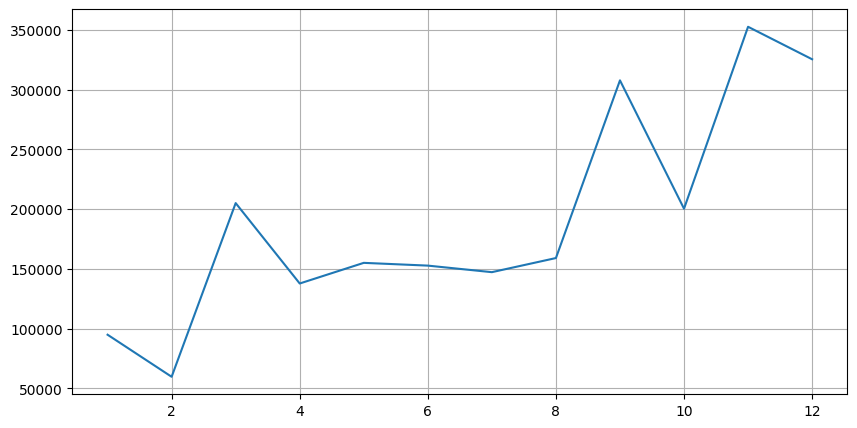

In [ ]:
plt.figure(figsize=(10,5))
plt.grid()
plt.plot(monthly_sales.index,monthly_sales.values)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Analysis')